## Assignment 8 - access keypoints in squat-video

#### Imports

In [10]:
import os
import sys
import mediapipe as mp
import cv2
import json
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
# Include functions in current path
sys.path.append(os.path.abspath("../functions"))
from assignment8_functions import extract_joint_nodes, save_to_json

print("Necesary imports sucessfully imported")

Necesary imports sucessfully imported


#### Define paths and implement functions

In [18]:
video_file = "../../EnisProject/data/test_squat.mp4"
model_file = "../data/pose_landmarker.task"
output_json = "../data/test_keypoints.json"

keypoints_data = extract_joint_nodes(video_file, model_file)

save_to_json(video_file, output_json, keypoints_data)
print("json file with keypoint data for each frame is created")


json file with keypoint data for each frame is created


#### Visualize mediapipe.tasks node placement in a frame

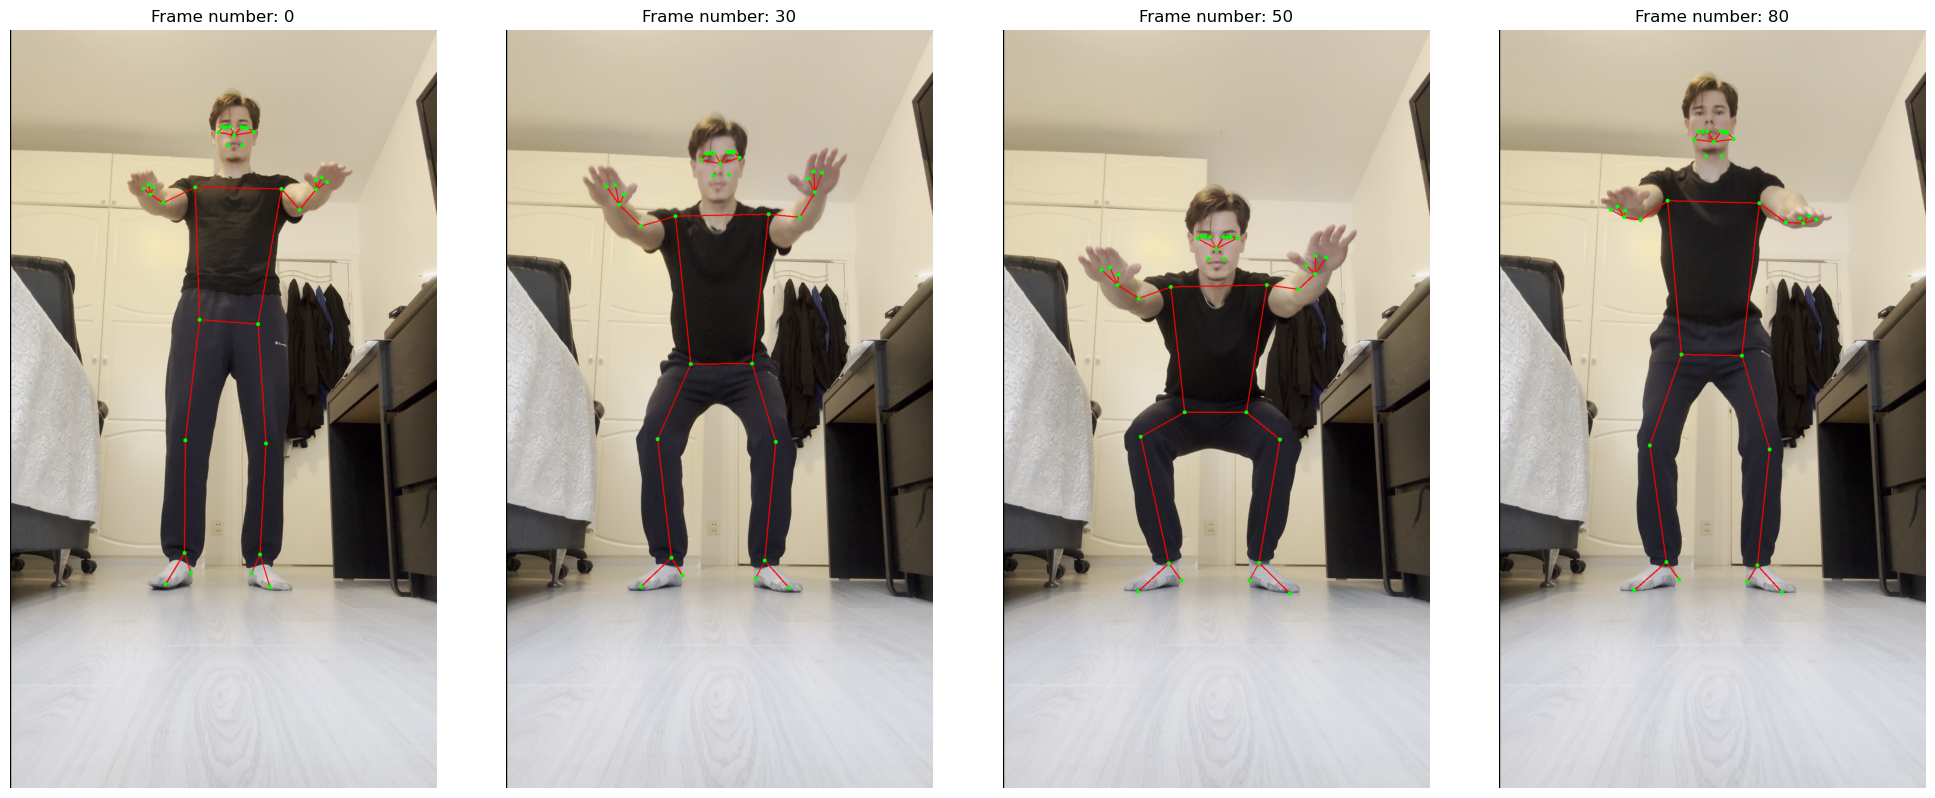

In [ ]:
with open(output_json, "r") as f:
    # Load json file into py dict
    keypoint_data = json.load(f)

    # Load video file
    cap = cv2.VideoCapture(video_file)

    # Choose frames and initialize subplot for each
    vis_frames = [0, 30, 50, 80]
    fig, axes = plt.subplots(1, len(vis_frames), figsize=(20,8))

    # Define which joints that should be connected
    keypoint_connections = [
    ("nose", "left_eye_inner"), ("left_eye_inner", "left_eye"),
    ("left_eye", "left_eye_outer"), ("nose", "right_eye_inner"),
    ("right_eye_inner", "right_eye"), ("right_eye", "right_eye_outer"),
    ("nose", "left_ear"), ("nose", "right_ear"),
    ("left_eye_outer", "left_ear"), ("right_eye_outer", "right_ear"),
    ("left_mouth_corner", "right_mouth_corner"),
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
    ("left_wrist", "left_pinky"), ("left_wrist", "left_index"),
    ("left_wrist", "left_thumb"), ("left_pinky", "left_ring"),
    ("left_index", "left_middle"), ("left_middle", "left_ring"),
    ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
    ("right_wrist", "right_pinky"), ("right_wrist", "right_index"),
    ("right_wrist", "right_thumb"), ("right_pinky", "right_ring"),
    ("right_index", "right_middle"), ("right_middle", "right_ring"),
    ("left_shoulder", "left_hip"), ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
    ("left_ankle", "left_heel"), ("left_ankle", "left_foot_index"),
    ("right_hip", "right_knee"), ("right_knee", "right_ankle"),
    ("right_ankle", "right_heel"), ("right_ankle", "right_foot_index")
    ]

    # Access each frame
    for indx, frame_numb in enumerate(vis_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_numb)
        sucess, frame = cap.read()

        if sucess:
            # Convert color-format and get height/width of frame
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w = frame_rgb.shape[:2]

            # Check if frame is in range and extract keypoint data
            if frame_numb < len(keypoint_data["frames"]):
                joints = keypoint_data["frames"][frame_numb]["joints"]

                # Draw joint connections
                for joint1, joint2 in keypoint_connections:
                    if joint1 in joints and joint2 in joints:
                        # Convert normalized coordinates to in frame coordinates
                        x1 = int(joints[joint1]["x"] * w)
                        y1 = int(joints[joint1]["y"] * h)
                        x2 = int(joints[joint2]["x"] * w)
                        y2 = int(joints[joint2]["y"] * h)
                        # Draw red lines between joints
                        cv2.line(frame_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
                
                # Draw nodes for keypoints
                for joint_name, coords in joints.items():
                    x = int(coords["x"] * w)
                    y = int(coords["y"] * h)
                    # Draw filled green circles for joints
                    cv2.circle(frame_rgb, (x, y), 5, (0, 255, 0), -1)
        
            # Plot for each chosen frame
            axes[indx].imshow(frame_rgb)
            axes[indx].set_title(f"Frame number: {frame_numb}")
            axes[indx].axis("off")
    
    cap.release()
    plt.tight_layout()
    plt.show()